In [ ]:
import numpy as np
hours = np.array([1,2,3,4,5,6,7,8,9,10])
scores = np.array([60,70,80,90,100,110,120,130,140,150])
predicted_score = 10 * 5 + 50
print("Best Fit Line Equation:")
print("score = 10 * hours + 50")
print("\nFor 5 hours → predicted score:", predicted_score)

Best Fit Line Equation:
score = 10 * hours + 50

For 5 hours → predicted score: 100


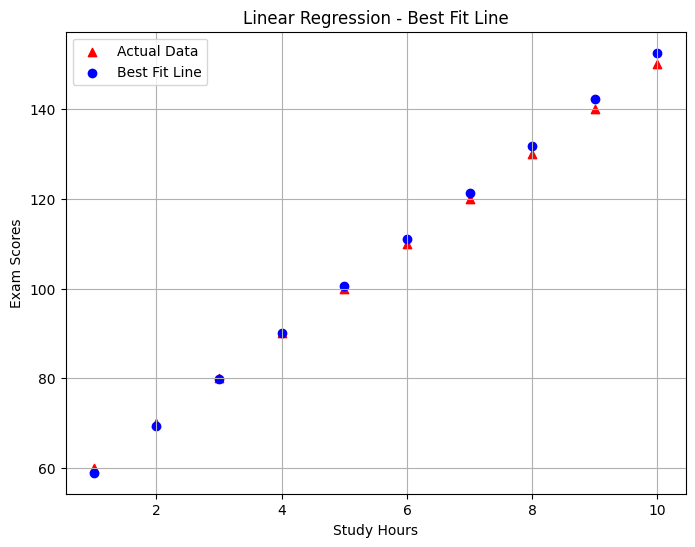

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
hours = np.array([1,2,3,4,5,6,7,8,9,10])
scores = np.array([60,70,80,90,100,110,120,130,140,150])
predicted_scores =10.41* hours + 48.52
plt.figure(figsize=(8,6))
plt.scatter(hours, scores, label="Actual Data" ,marker="^",color="red")
plt.scatter(hours, predicted_scores, label="Best Fit Line",color="blue")
plt.xlabel("Study Hours")
plt.ylabel("Exam Scores")
plt.title("Linear Regression - Best Fit Line")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
x = np.array([1,2,3,4,5], dtype=float)
y = np.array([60,70,80,90,100], dtype=float)
m = 0
c = 0
learning_rate = 0.01
epochs = 1000
n = len(x)
for i in range(epochs):
    y_pred = m * x + c
    error = y - y_pred
    mse = np.mean(error ** 2)
    dm = (-2/n) * np.sum(x * error)
    dc = (-2/n) * np.sum(error)
    m = m - learning_rate * dm
    c = c - learning_rate * dc
    if i % 100 == 0:
        print(f"Epoch {i}")
        print(f"MSE = {mse:.2f}")
        print(f"m = {m:.2f}, c = {c:.2f}")
        print("----------------------")
print("\nFinal Best Fit Line:")
print(f"y = {m:.2f}x + {c:.2f}")

Epoch 0
MSE = 6600.00
m = 5.20, c = 1.60
----------------------
Epoch 100
MSE = 177.90
m = 18.63, c = 18.84
----------------------
Epoch 200
MSE = 90.37
m = 16.15, c = 27.79
----------------------
Epoch 300
MSE = 45.90
m = 14.38, c = 34.17
----------------------
Epoch 400
MSE = 23.32
m = 13.12, c = 38.72
----------------------
Epoch 500
MSE = 11.84
m = 12.23, c = 41.96
----------------------
Epoch 600
MSE = 6.02
m = 11.59, c = 44.27
----------------------
Epoch 700
MSE = 3.06
m = 11.13, c = 45.92
----------------------
Epoch 800
MSE = 1.55
m = 10.81, c = 47.09
----------------------
Epoch 900
MSE = 0.79
m = 10.57, c = 47.93
----------------------

Final Best Fit Line:
y = 10.41x + 48.52


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
experience = np.array([1,2,3,4,5,6,7,8,9,10,11,12,13,14,15])
salary = np.array([35,38,42,48,55,60,65,70,76,82,87,92,96,100,105])
X = experience.reshape(-1, 1)
y = salary
X_train, X_test, y_train, y_test = train_test_split(
 X, y,
 test_size=0.2,
 random_state=42
)
print(f"Training samples : {len(X_train)}")
print(f"Testing samples : {len(X_test)}")

Training samples : 12
Testing samples : 3


In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
print(f"Slope (coefficient) : {model.coef_[0]:.2f}")
print(f"Intercept : {model.intercept_:.2f}")
y_pred = model.predict(X_test)
for actual, predicted in zip(y_test, y_pred):
 print(f"Actual: {actual:>5} | Predicted: {predicted:>7.1f} | "
 f"Error: {predicted - actual:+.1f}")

Slope (coefficient) : 5.22
Intercept : 27.94
Actual:    82 | Predicted:    80.2 | Error: -1.8
Actual:    92 | Predicted:    90.6 | Error: -1.4
Actual:    35 | Predicted:    33.2 | Error: -1.8


In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
y_actual = np.array([500, 300, 700, 450, 600])
y_pred = np.array([480, 320, 690, 460, 590])
r2 = r2_score(y_actual, y_pred)
mae = mean_absolute_error(y_actual, y_pred)
rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
print(f"R² Score : {r2:.4f} → model explains {r2*100:.1f}% of variance")
print(f"MAE : {mae:.1f} → avg error ± {mae:.0f} units")
print(f"RMSE : {rmse:.1f} → penalised avg error {rmse:.0f} units")

R² Score : 0.9880 → model explains 98.8% of variance
MAE : 14.0 → avg error ± 14 units
RMSE : 14.8 → penalised avg error 15 units


In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
np.random.seed(42)
n = 100
data = pd.DataFrame({
 'experience': np.random.randint(0, 20, n),
 'education': np.random.randint(12, 20, n),
 'age': np.random.randint(22, 55, n),
 })
data['salary'] = (data['experience'] * 4500 +data['education'] * 2000 +data['age'] * 300 +np.random.normal(0, 3000, n) +10000)
X = data[['experience', 'education', 'age']]
y = data['salary']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
for feat, coef in zip(X.columns, model.coef_):
 print(f" {feat:12s}: ${coef:,.0f} per unit increase")
print(f" Base salary (intercept): ${model.intercept_:,.0f}")
y_pred = model.predict(X_test)
print(f"\nR² : {r2_score(y_test, y_pred):.3f}")
print(f"MAE : ${mean_absolute_error(y_test, y_pred):,.0f}")

 experience  : $4,534 per unit increase
 education   : $2,203 per unit increase
 age         : $266 per unit increase
 Base salary (intercept): $7,694

R² : 0.988
MAE : $2,219


lab

In [ ]:
# Step 1: Create the Dataset
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
np.random.seed(42)
n = 200
appliance_types = ['Basic', 'Standard', 'Premium']
df = pd.DataFrame({
    'units_used': np.random.randint(50, 600, n),
    'family_members': np.random.randint(1, 8, n),
    'appliance_type': np.random.choice(appliance_types, n),
    'usage_hours': np.random.randint(2, 20, n),
})
app_map = {'Basic': 0.8, 'Standard': 1.0, 'Premium': 1.5}
noise = np.random.normal(0, 500, n)
df['current_bill'] = (
    df['units_used'] * 8 +
    df['family_members'] * 300 +
    df['usage_hours'] * 150 +
    df['appliance_type'].map(app_map) * 2000 +
    noise
).astype(int)
print(df.head(8).to_string(index=False))
print(f"\nDataset shape : {df.shape}")
print(df.describe()[['units_used','family_members','usage_hours','current_bill']].round(0))

 units_used  family_members appliance_type  usage_hours  current_bill
        152               3          Basic           13          4862
        485               3          Basic            8          7681
        320               3          Basic           11          6331
        156               4       Standard            8          4936
        121               6       Standard            4          5044
         70               1          Basic           14          4019
        171               4        Premium           14          8511
        516               3       Standard           19         10318

Dataset shape : (200, 5)
       units_used  family_members  usage_hours  current_bill
count       200.0           200.0        200.0         200.0
mean        324.0             4.0         11.0        7482.0
std         156.0             2.0          5.0        1790.0
min          51.0             1.0          2.0        3095.0
25%         193.0             2.0      

In [ ]:
# Step 2: Encode & Prepare Features
le = LabelEncoder()
df['appliance_enc'] = le.fit_transform(df['appliance_type'])
features = ['units_used', 'family_members', 'usage_hours', 'appliance_enc']
X = df[features]
y = df['current_bill']
print(df[['appliance_type', 'appliance_enc']]
      .drop_duplicates()
      .sort_values('appliance_enc'))
print(f"\nFeature matrix shape : {X.shape}")
print(f"Target vector shape : {y.shape}")

  appliance_type  appliance_enc
0          Basic              0
6        Premium              1
3       Standard              2

Feature matrix shape : (200, 4)
Target vector shape : (200,)


In [ ]:
# Step 3: Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
print(f"Training samples : {len(X_train)} ({len(X_train)/len(X)*100:.0f}%)")
print(f"Testing samples : {len(X_test)} ({len(X_test)/len(X)*100:.0f}%)")
print(f"Feature names : {features}")

Training samples : 160 (80%)
Testing samples : 40 (20%)
Feature names : ['units_used', 'family_members', 'usage_hours', 'appliance_enc']


In [ ]:
# Step 4: Train the Model
model = LinearRegression()
model.fit(X_train, y_train)
print("Learned Coefficients:")
print("-" * 45)
for feat, coef in zip(features, model.coef_):
    direction = "↑" if coef > 0 else "↓"
    print(f" {feat:15s}: Rs {coef:>10,.0f} {direction}")
print(f" {'intercept':15s}: Rs {model.intercept_:>10,.0f}")
print("-" * 45)

Learned Coefficients:
---------------------------------------------
 units_used     : Rs          8 ↑
 family_members : Rs        285 ↑
 usage_hours    : Rs        171 ↑
 appliance_enc  : Rs        271 ↑
 intercept      : Rs      1,551
---------------------------------------------


In [ ]:
# Step 5: Evaluate the Model
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("=" * 40)
print(" MODEL EVALUATION REPORT")
print("=" * 40)
print(f"R² Score : {r2:.4f} {' Excellent' if r2>0.9 else 'Good' if r2>0.8 else 'Needs work'}")
print(f"MAE : Rs {mae:>10,.0f}")
print(f"RMSE : Rs {rmse:>10,.0f}")
print("=" * 40)
print("\nSample Predictions:")
print(f"{'Actual':>10} | {'Predicted':>10} | {'Error':>10}")
print("-" * 36)
for a, p in zip(y_test[:8], y_pred[:8]):
    print(f"{a:>10,} | {p:>10,.0f} | {p-a:>+10,.0f}")

 MODEL EVALUATION REPORT
R² Score : 0.8550 Good
MAE : Rs        546
RMSE : Rs        720

Sample Predictions:
    Actual |  Predicted |      Error
------------------------------------
     4,761 |      3,255 |     -1,506
     6,368 |      5,421 |       -947
    10,080 |      9,548 |       -532
     4,464 |      4,834 |       +370
     6,789 |      6,584 |       -205
    10,530 |     10,314 |       -216
     7,700 |      8,152 |       +452
    11,545 |     10,977 |       -568


In [ ]:
# Step 6: Predict New Current Bills
new_houses = pd.DataFrame({
    'units_used': [120, 350, 500, 220],
    'family_members': [3, 5, 7, 2],
    'usage_hours': [5, 10, 15, 7],
    'appliance_enc': [0, 2, 1, 2],
    'appliance_lbl': ['Basic', 'Standard', 'Premium', 'Standard'],
})
predictions = model.predict(new_houses[features])
print("\n CURRENT BILL PREDICTIONS")
print("=" * 60)
for i, (_, row) in enumerate(new_houses.iterrows()):
    print(f" House {i+1}: {row.units_used} units | "
          f"{row.family_members} members | "
          f"{row.usage_hours}hrs usage | "
          f"{row.appliance_lbl}")
    print(f" Estimated Current Bill → Rs {predictions[i]:>10,.0f}")
    print()


 CURRENT BILL PREDICTIONS
 House 1: 120 units | 3 members | 5hrs usage | Basic
 Estimated Current Bill → Rs      4,258

 House 2: 350 units | 5 members | 10hrs usage | Standard
 Estimated Current Bill → Rs      8,135

 House 3: 500 units | 7 members | 15hrs usage | Premium
 Estimated Current Bill → Rs     10,534

 House 4: 220 units | 2 members | 7hrs usage | Standard
 Estimated Current Bill → Rs      5,688

